## Graphs Processing

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# task = "LinReg"
task = "BinClass"
path = f"../scripts/results/{task}_Tridiag_grid_search_20_by_2.csv"

# /workspace/scripts/results/BinClass_Aniso_data_iso_weights_grid_search_20_by_2.csv

# /workspace/scripts/results/BinClass_gradients_dynamics_20_by_2.csv

path_1 = f"../scripts/results/{task}_Synth_seeds_20_by_2.csv"
path_2 = f"../scripts/results/{task}_AU_seeds_14_by_2.csv"
path_3 = f"../scripts/results/{task}_Splice_seeds_287_by_3.csv"

In [16]:
df_bin = pd.read_csv(path)

# df_1 = pd.read_csv(path_1)
# df_2 = pd.read_csv(path_2)
# df_3 = pd.read_csv(path_3)

# df_1["dataset"] = ["Synthetic"] * len(df_1["epoch"])
# df_2["dataset"] = ["Australian"] * len(df_2["epoch"])
# df_3["dataset"] = ["Splice"] * len(df_3["epoch"])

# df_bin = pd.concat([df_1, df_2, df_3])
# df_linreg = pd.concat([df_3, df_4])

df_bin.head(15)


,Unnamed: 0,epoch,optimizer,lr,loss,accuracy,mode,rank,eps,X_type,avg_epoch_time,epoch_time,batch_size,data_seed
0,0,0,FullAdaGrad,0.1,0.871564,0.283333,test,NaN,0.5,X true,0.000000,0.000000,1,10
1,1,0,FullAdaGrad,0.1,0.812793,0.420833,train,NaN,0.5,X true,0.000000,0.000000,1,10
2,2,1,FullAdaGrad,0.1,0.262409,0.933333,test,NaN,0.5,X true,0.856749,0.856749,1,10
3,3,1,FullAdaGrad,0.1,0.258719,0.937500,train,NaN,0.5,X true,0.856749,0.856749,1,10
4,4,2,FullAdaGrad,0.1,0.213460,0.933333,test,NaN,0.5,X true,0.704940,1.409880,1,10
5,5,2,FullAdaGrad,0.1,0.205833,0.958333,train,NaN,0.5,X true,0.704940,1.409880,1,10
6,6,3,FullAdaGrad,0.1,0.193333,0.933333,test,NaN,0.5,X true,0.654871,1.964614,1,10
7,7,3,FullAdaGrad,0.1,0.179850,0.958333,train,NaN,0.5,X true,0.654871,1.964614,1,10
8,8,4,FullAdaGrad,0.1,0.181930,0.933333,test,NaN,0.5,X true,0.631989,2.527954,1,10
9,9,4,FullAdaGrad,0.1,0.163259,0.958333,train,NaN,0.5,X true,0.631989,2.527954,1,10


In [17]:
import numpy as np 

grouped_accuracies = df_bin.groupby(['dataset', 'optimizer'])['accuracy'].apply(list)
table_data = grouped_accuracies.unstack()

# --- 3. Identify the Best Optimizer for Each Dataset ---
# Calculate the mean accuracy for each optimizer on each dataset
mean_accuracies = table_data.applymap(np.mean)

# Find the name of the optimizer with the highest mean accuracy for each dataset
best_optimizer_series = mean_accuracies.idxmax(axis=1)

# --- 4. Create the Final Summary Table ---
summary_rows = []
for dataset, best_optimizer_name in best_optimizer_series.items():
    # Retrieve the list of accuracies for the best optimizer
    acc_list = table_data.loc[dataset, best_optimizer_name]
    
    # Calculate mean and standard deviation
    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)
    
    # Format the accuracy string
    formatted_accuracy = f"{mean_acc:.1%} ± {std_acc:.1%}"
    
    # Append the results for the new table
    summary_rows.append({
        "Best Optimizer": best_optimizer_name,
        "Best Accuracy": formatted_accuracy
    })

# Create a new DataFrame from the collected rows
best_accuracy_table = pd.DataFrame(summary_rows, index=table_data.index)


# --- 5. Display the Final Table ---
print("Best Performing Optimizer per Dataset\n")
print(best_accuracy_table.to_string())

KeyError: 'dataset'

In [ ]:
df = df_bin[(df_bin['mode'] == 'test') & (df_bin['optimizer'].str.contains("AdaGram"))]
df = df[['accuracy', 'optimizer', 'lr', 'rank', 'batch_size', 'eps']]
df.head()

,accuracy,optimizer,lr,rank,batch_size,eps
0,0.533333,AdaGramPS rank 1,0.01,1.0,1,0.01
2,0.666667,AdaGramPS rank 1,0.01,1.0,1,0.01
4,0.666667,AdaGramPS rank 1,0.01,1.0,1,0.01
6,0.666667,AdaGramPS rank 1,0.01,1.0,1,0.01
8,0.650000,AdaGramPS rank 1,0.01,1.0,1,0.01


In [10]:
!pip install plotly
!pip install --upgrade nbformat

In [18]:

import pandas as pd
import plotly.express as px

df_grid_search = df_bin
# 1. Load your experiment results
try:
    # This line should be adjusted to load your actual data
    df = df_grid_search[(df_grid_search['mode'] == 'test') & (df_grid_search['optimizer'].str.contains("AdaGram"))]
    # df = df[['accuracy', 'optimizer', 'lr', 'rank', 'batch_size', 'eps']]
except (NameError, FileNotFoundError): # More robust error handling
    # Create a dummy DataFrame if the file doesn't exist for demonstration
    data = {
        'lr': [0.01, 0.01, 0.001, 0.001, 0.05, 0.05],
        'batch_size': [32, 64, 32, 64, 32, 64],
        'eps': [1e-8, 1e-7, 1e-8, 1e-7, 1e-8, 1e-7],
        'rank': [10, 20, 10, 20, 10, 20],
        'accuracy': [0.85, 0.88, 0.91, 0.90, 0.82, 0.89]
    }
    df = pd.DataFrame(data)

# 2. Define dimensions and the performance metric
hyperparameter_dims = ['lr', 'batch_size',"eps", "rank",'accuracy']
hyperparameter_cols = ['lr', 'batch_size', "eps", "rank",]
performance_metric = 'accuracy'
time_col = 'epoch_time'

df_sorted = df.sort_values(
    by=[performance_metric, time_col], 
    ascending=[False, True]
)

# 3. Drop duplicates based on hyperparameters, keeping the first entry
#    Because of our sorting, the first entry for each group is now guaranteed
#    to be the earliest occurrence of its highest accuracy.
df_earliest_best = df_sorted.drop_duplicates(
    subset=hyperparameter_cols, 
    keep='first'
)

# 3. Create the parallel coordinates plot
fig = px.parallel_coordinates(
    df_earliest_best,
    dimensions=hyperparameter_dims,
    color=performance_metric,
    color_continuous_scale=px.colors.diverging.RdBu_r,
    labels={
        "lr": "Learning Rate",
        "batch_size": "Batch Size",
        "eps": "Epsilon",
        "rank": "Rank",
        "accuracy": "accuracy"
    },
    title="Hyperparameter Optimization Analysis"
)

# 4. Update layout to make the plot taller
fig.update_layout(
    height=800  # Set the desired height of the plot in pixels
)

# 5. Display the interactive plot
fig.show()
 


In [19]:
import pandas as pd
import numpy as np
from ruamel.yaml import YAML
import os

def find_and_update_best_params(df_grid_search, config_path):
    """
    Finds the best hyperparameters for each optimizer based on the earliest
    minimum loss and updates a YAML configuration file with these parameters,
    using block-style formatting for lists.

    Args:
        df_grid_search (pd.DataFrame): DataFrame containing experiment results.
        config_path (str): The file path to the YAML configuration file.
    """
    # 1. Filter for test results and extract base optimizer name
    df_test = df_grid_search[df_grid_search['mode'] == 'test'].copy()
    df_test['base_optimizer'] = df_test['optimizer'].apply(lambda x: x.split(' ')[0])

    # 2. Sort by loss (ascending) and then by epoch (ascending)
    df_sorted = df_test.sort_values(by=['loss', 'epoch'], ascending=[True, True])

    # 3. Get the single best parameter set for each base optimizer
    df_best_per_optimizer = df_sorted.drop_duplicates(subset=['base_optimizer'], keep='first')
    
    print("--- Best performing parameters found for each optimizer ---")
    print(df_best_per_optimizer[['base_optimizer', 'optimizer', 'accuracy', 'epoch', 'lr', 'batch_size', 'eps', 'rank']])
    print("-" * 60)

    # 4. Load the YAML configuration file and set the desired style
    yaml = YAML()
    yaml.preserve_quotes = True
    
    # --- KEY CHANGE: Set the list format to block style ---
    yaml.default_flow_style = True

    try:
        with open(config_path, 'r') as f:
            config = yaml.load(f)
    except FileNotFoundError:
        print(f"Error: Configuration file not found at {config_path}")
        return

    # 5. Iterate through the best results and update the config
    for _, row in df_best_per_optimizer.iterrows():
        opt_name = row['base_optimizer'] 
        
        if opt_name in config['optimizers']:
            print(f"Updating configuration for: {opt_name}")
            
            config['optimizers'][opt_name]['learning_rates'] = [row['lr']]
            config['optimizers'][opt_name]['batch_size'] = [row['batch_size']]
            
            if pd.notna(row['eps']) and str(row['eps']).lower() != 'nan':
                config['optimizers'][opt_name]['eps'] = [row['eps']]
            else:
                config['optimizers'][opt_name]['eps'] = ['nan']

            if config['optimizers'][opt_name].get('requires_rank') and pd.notna(row['rank']):
                config['optimizers'][opt_name]['ranks'] = [int(row['rank'])]
        else:
            print(f"Warning: Optimizer '{opt_name}' from results not found in config. Skipping.")

    # 6. Write the updated configuration back to the file
    try:
        with open(config_path, 'w') as f:
            yaml.dump(config, f)
        print(f"\nConfiguration file '{config_path}' has been successfully updated.")
    except Exception as e:
        print(f"Error writing to configuration file: {e}")

find_and_update_best_params(df_grid_search, "../scripts/configs/classification/config_Synth_Aniso.yaml")


--- Best performing parameters found for each optimizer ---
     base_optimizer         optimizer  accuracy  epoch   lr  batch_size   eps  \
7094    Vanilla_SGD       Vanilla_SGD  0.933333     19  0.1           1   NaN   
82      FullAdaGrad       FullAdaGrad  0.916667     20  0.1           1  0.20   
6214  Torch_Adagrad     Torch_Adagrad  0.916667     20  0.1           1  0.01   
1016      AdaGramPS  AdaGramPS rank 1  0.916667      4  0.1           1  0.50   

      rank  
7094   NaN  
82     NaN  
6214   NaN  
1016   1.0  
------------------------------------------------------------
Updating configuration for: Vanilla_SGD
Updating configuration for: FullAdaGrad
Updating configuration for: Torch_Adagrad
Updating configuration for: AdaGramPS

Configuration file '../scripts/configs/classification/config_Synth_Aniso.yaml' has been successfully updated.


In [4]:
df_long = df_bin.melt(
    id_vars=['epoch', 'dataset','optimizer', 'mode', 'batch_size'],       # columns to keep
    value_vars=['loss', 'accuracy'],    # columns to melt
    var_name='metric', value_name='value'
)

df_long.head()

,epoch,dataset,optimizer,mode,batch_size,metric,value
0,0,Synthetic,AdaGramPS rank 1,test,1,loss,0.676284
1,0,Synthetic,AdaGramPS rank 1,train,1,loss,0.666769
2,1,Synthetic,AdaGramPS rank 1,test,1,loss,0.315198
3,1,Synthetic,AdaGramPS rank 1,train,1,loss,0.236529
4,2,Synthetic,AdaGramPS rank 1,test,1,loss,0.270308


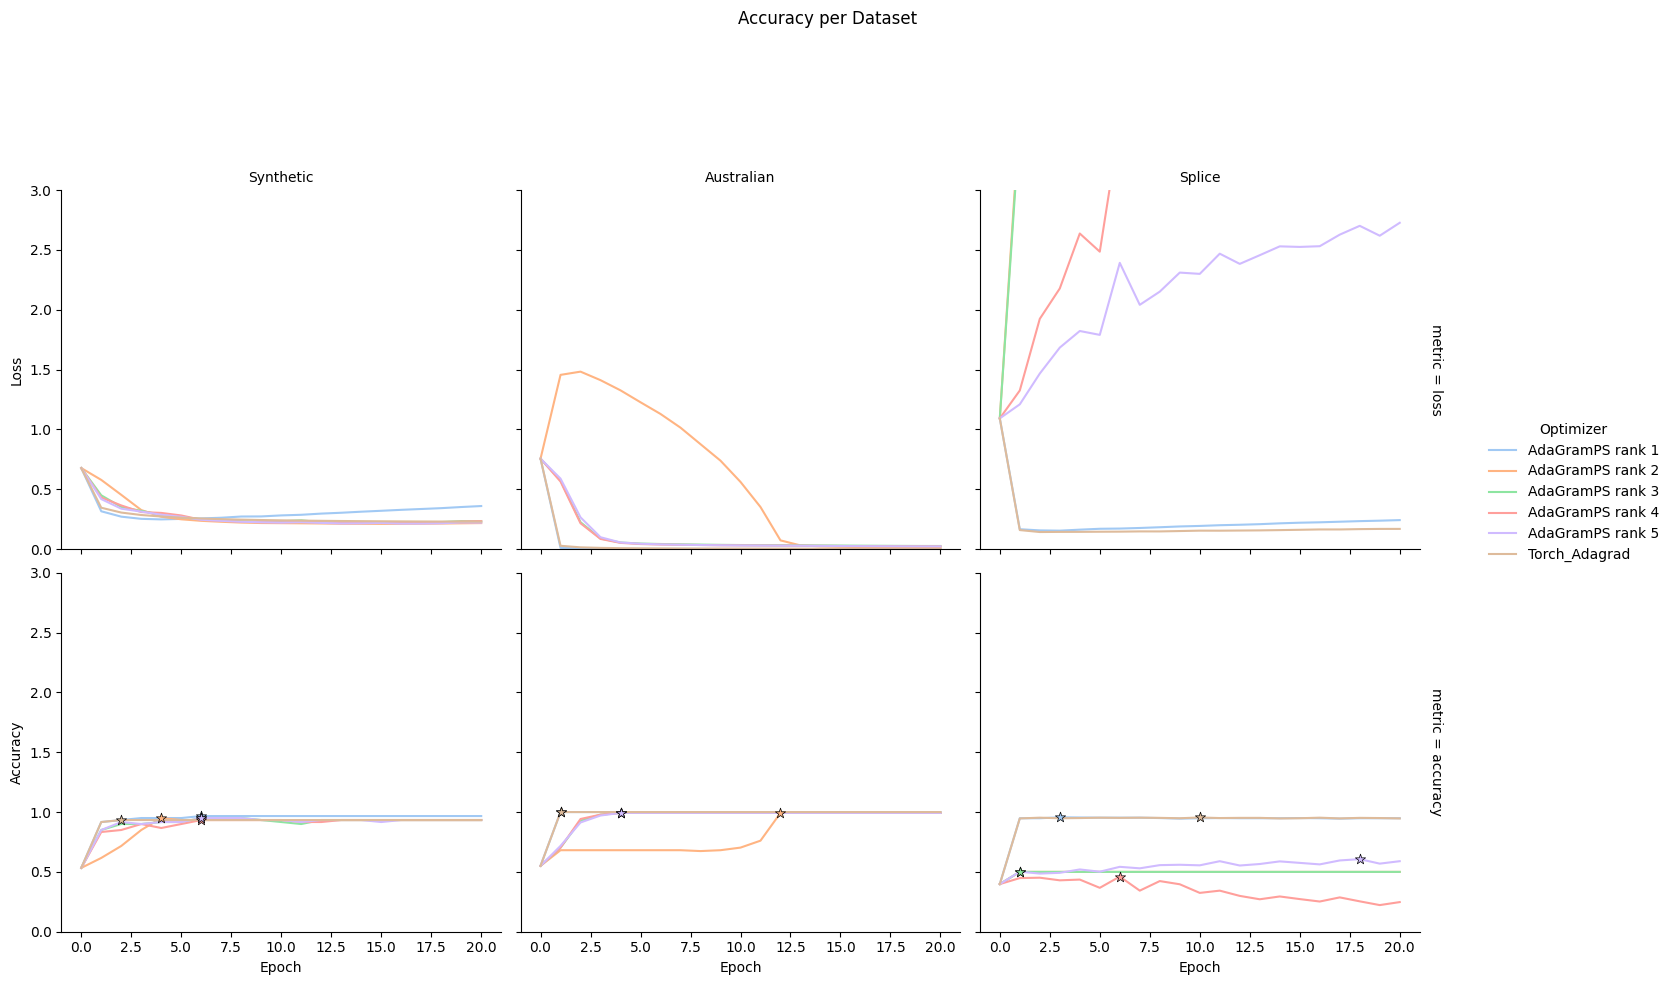

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume df_long is already loaded

# Filter your data for mode == 'test' and batch_size == 1
df_plot = df_long.query('mode == "test" and batch_size == 1')

def mark_best_accuracy(data, **kwargs):
    # Only process the facet with 'accuracy'
    if data['metric'].iloc[0] == 'accuracy':
        # Find best point for each optimizer
        best_points = data.loc[data.groupby(['optimizer'])['value'].idxmax()]
        color = kwargs.get("color", "C0")
        plt.scatter(
            best_points['epoch'],
            best_points['value'],
            color=color,
            marker='*',
            s=60,
            edgecolor='black',
            linewidth=0.5,
            zorder=10
        )

# Draw the grid as usual
g = sns.FacetGrid(
    df_plot,
    row='metric', col='dataset',
    hue='optimizer', palette='pastel',
    margin_titles=True, height=5
)
g.map(sns.lineplot, 'epoch', 'value')

# Set y-axis for accuracy only
g.set_axis_labels('Epoch', 'Value')

g.axes[0, 0].set_ylim(0, 3)


for ax, metric in zip(g.axes[:,0], g.row_names):
    if metric == 'accuracy':
        ax.set_ylabel('Accuracy')
        # ax.set_ylim(0, 1.1)   # fixed y-limits for accuracy row
    else:
        ax.set_ylabel('Loss')
        # ax.set_ylim(auto=True)
        # ax.set_ylim(0, 10)  # OR: do nothing for loss, keeps autoscale

g.map_dataframe(mark_best_accuracy)

g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Accuracy per Dataset')
g.add_legend(title='Optimizer')

plt.show()


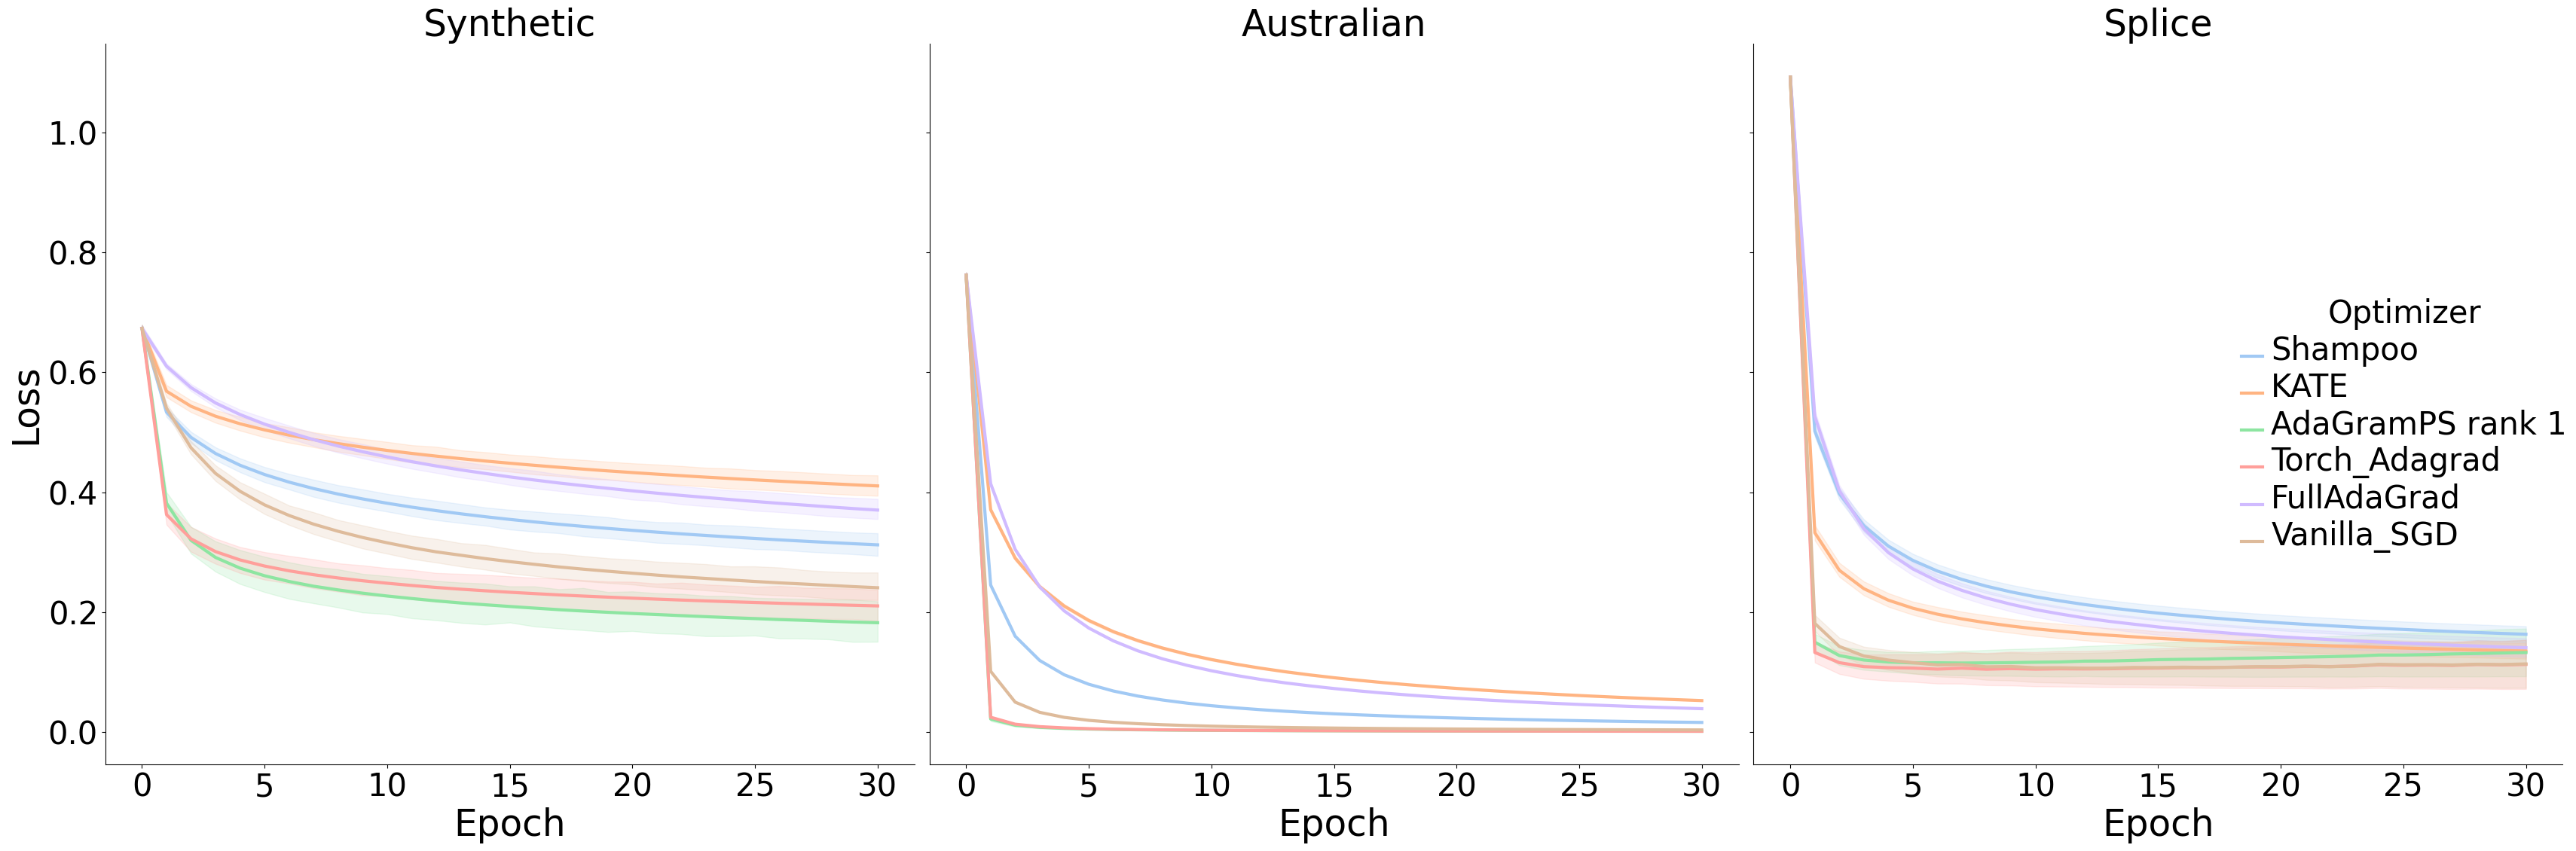

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Draw the grid as usual
dir= "./plots"

g = sns.FacetGrid(
    df_bin,
    col='dataset',
    hue='optimizer',
    palette='pastel',
    margin_titles=True,
    height=12,  # Increased from 5 to 8 to make each facet taller
    aspect=0.9
    
)

# 2. Map the lineplot to the grid
g.map(sns.lineplot, 'epoch', 'loss', linewidth=3)

# 3. Set the font sizes for all text elements
# Set facet titles and axis labels to fontsize 24
g.set_titles(col_template="{col_name}", size=35)
g.set_axis_labels("Epoch", "Loss", fontsize=35)

# Set the tick label font size to 20 for all axes
g.tick_params(axis='both', which='major', labelsize=30)

# 4. Add and format the legend
# Set legend title to 24 and legend item labels to 20
g.add_legend(title='Optimizer')

# 2. Now, access the legend's title object and set its font size.
g.legend.get_title().set_fontsize(30)

# 2. To set the font size of the legend labels, you iterate through them
for text in g.legend.get_texts():
    text.set_fontsize(30)

# 5. Adjust layout and add an overall title
g.fig.subplots_adjust(top=0.8) # Make room for the main title
# Display the plot
output_path = os.path.join(dir, 'Losses_classification.pdf')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()



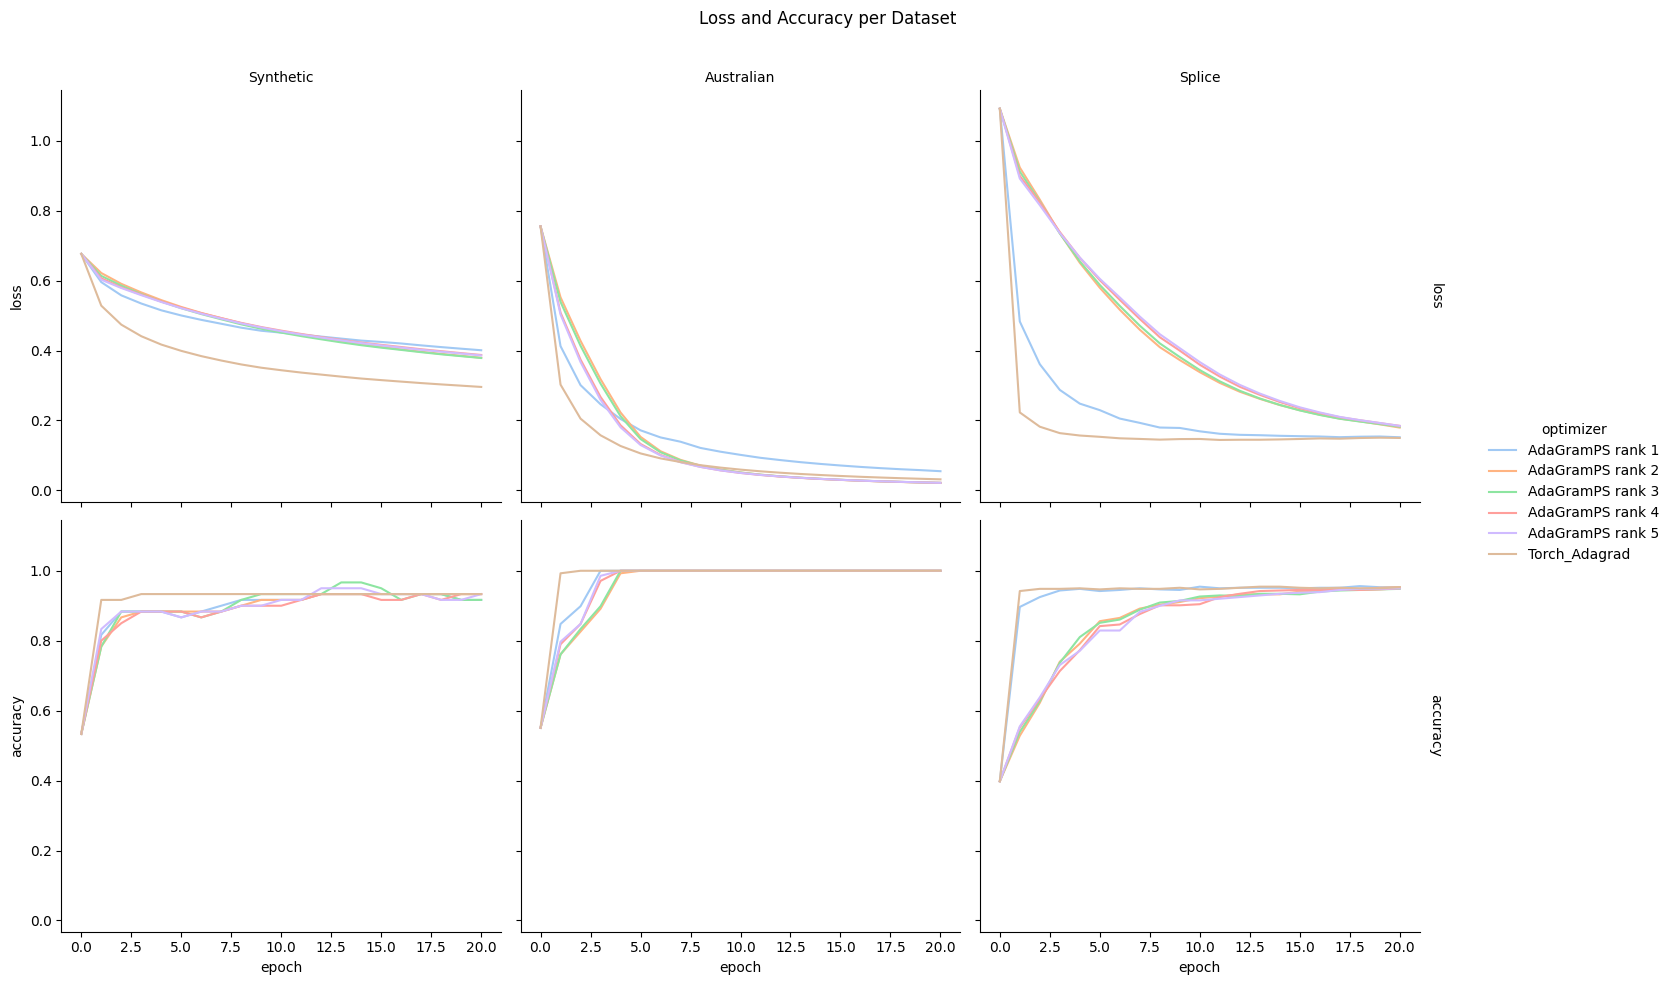

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_long.query('mode == "test" and batch_size == 32'),
    row='metric', col='dataset',
    hue='optimizer', palette='pastel',
    margin_titles=True, height=5
)
g.map(sns.lineplot, 'epoch', 'value')
g.set_axis_labels('epoch', '')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Loss and Accuracy per Dataset')

for ax, metric in zip(g.axes[:,0], ['loss', 'accuracy']):
    ax.set_ylabel(metric)

g.add_legend()  # <-- Add this to show the hue variable legend

plt.show()


In [23]:
df_bin = pd.read_csv("../scripts/results/BinClass_MNIST_all_ranks_784_by_10.csv")
df_bin.head()

,Unnamed: 0,epoch,optimizer,lr,loss,accuracy,mode,rank,eps,X_type,avg_epoch_time,epoch_time,batch_size,data_seed
0,0,0,AdaGramPS rank 1,0.1,2.334469,0.083833,test,1.0,0.1,X true,0.000000,0.000000,32,10.0
1,1,0,AdaGramPS rank 1,0.1,2.333639,0.079917,train,1.0,0.1,X true,0.000000,0.000000,32,10.0
2,2,1,AdaGramPS rank 1,0.1,0.569475,0.866667,test,1.0,0.1,X true,4.587944,4.587883,32,NaN
3,3,1,AdaGramPS rank 1,0.1,0.566700,0.863875,train,1.0,0.1,X true,4.587944,4.587883,32,NaN
4,4,2,AdaGramPS rank 1,0.1,0.446945,0.881833,test,1.0,0.1,X true,4.669970,4.751410,32,NaN


/tmp/ipykernel_2885/1118813971.py:13: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_2885/1118813971.py:17: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



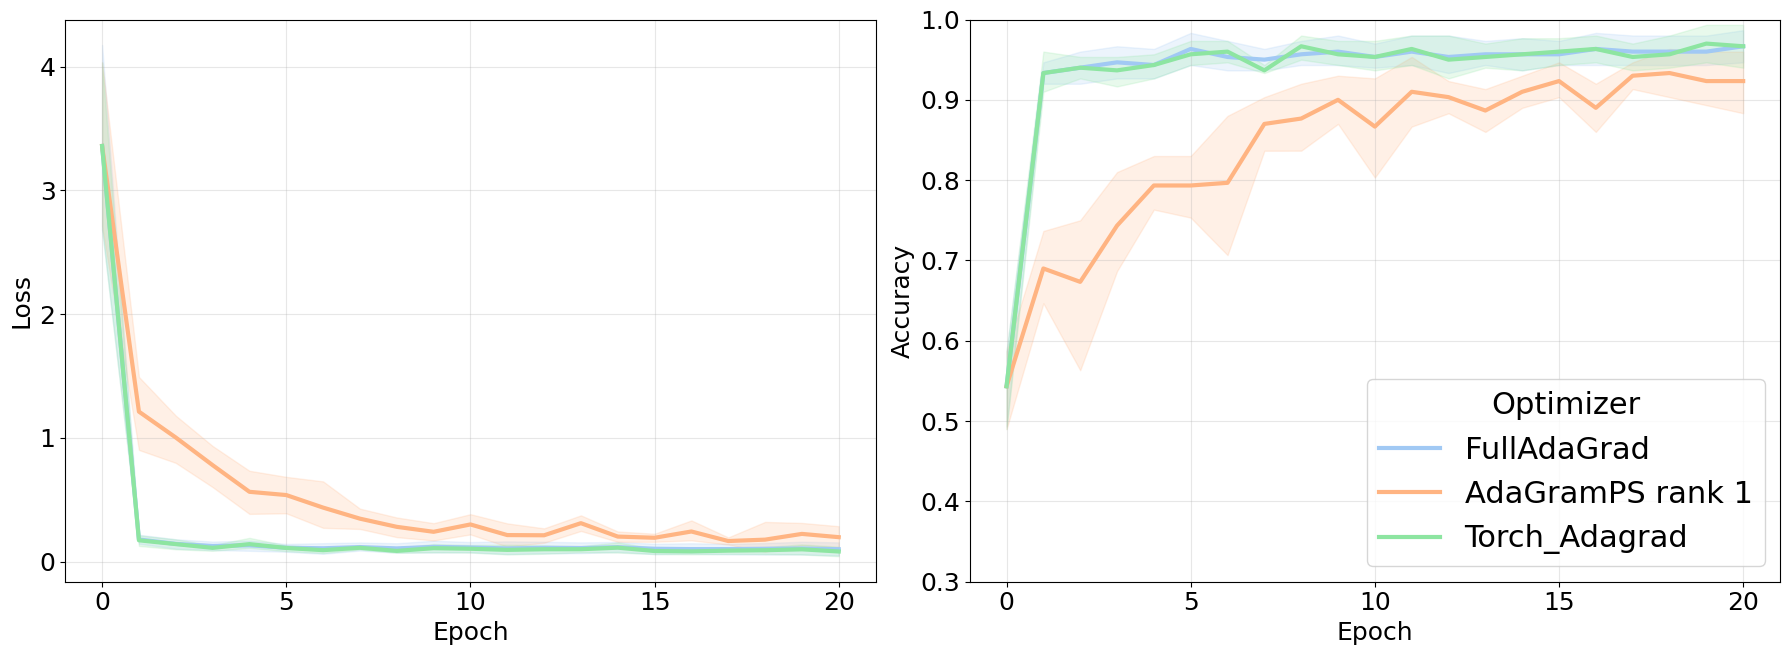

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import os
import numpy as np

dir = './plots'

# Your existing data preparation code...
df_test = df_bin[df_bin['mode'] == 'test']
df_test = df_test.query("optimizer != 'Vanilla_SGD' ")
best_accuracies = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['accuracy'].idxmax()]
).reset_index(drop=True)

best_losses = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['loss'].idxmin()]
).reset_index(drop=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Color mapping
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}

# Plot loss over epochs (left subplot)
sns.lineplot(data=df_test, x='epoch', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])


# axes[0].set_title('Loss over Epochs', fontsize=22)
axes[0].set_xlabel('Epoch', fontsize=18)
axes[0].set_ylabel('Loss', fontsize=18)
# axes[0].set_yscale('log')  # Keep log scale for loss
axes[0].grid(True, alpha=0.3)

# for ax in grid.axes.flat:
    # --- Add this line to set the x-axis limit ---

# Plot accuracy over epochs (right subplot)
sns.lineplot(data=df_test, x='epoch', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])

# Add scatter points
# sns.scatterplot(data=best_accuracies.query("optimizer != 'Torch_Adagrad'"), x='epoch', y='accuracy', hue='optimizer', 
#                 s=50, edgecolor='black', linewidth=1.5, legend=False, zorder=5, palette=color_map, ax=axes[1])

# # Add star marker for Torch_Adagrad
# torch_adagrad_best_row = best_accuracies[best_accuracies['optimizer'] == 'Torch_Adagrad']
# if not torch_adagrad_best_row.empty:
#     torch_adagrad_best = torch_adagrad_best_row.iloc[0]
#     axes[1].scatter(torch_adagrad_best['epoch'], torch_adagrad_best['accuracy'], 
#                    s=200, marker='*', c=color_map['Torch_Adagrad'], edgecolors='black', linewidths=1.5, 
#                    zorder=10)

# axes[1].set_title('Accuracy over Epochs', fontsize=22)
axes[1].set_xlabel('Epoch', fontsize=18)
axes[1].set_ylabel('Accuracy', fontsize=18)


# FIX 1: Remove log scale from accuracy plot
# axes[1].set_yscale('log')  # Comment this out or remove it

# FIX 2: Set better y-axis limits for accuracy
axes[1].set_ylim(0.5, 1.0)  # Adjust range to show meaningful differences

# FIX 3: Improve tick formatting
for ax in axes:
    ax.tick_params(axis='x', which='major', labelsize=18)
    ax.tick_params(axis='y', which='major', labelsize=18)
    
# FIX 4: Set specific tick locations for better readability
# axes[0].set_xticks(range(0, 21, 5))  # Ticks every 5 epochs
axes[1].set_xticks(range(0, 21, 5))
axes[1].set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # Clear accuracy intervals

handles, labels = axes[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axes[1].legend(unique_labels.values(), unique_labels.keys(),
               fontsize=22, loc='lower right', title='Optimizer', title_fontsize='22')

# Legend with better positioning
# handles, labels = axes[1].get_legend_handles_labels()
# star_handle = Line2D([0], [0], marker='*', color=color_map['Torch_Adagrad'], label='Torch_Adagrad',
#                       markeredgecolor='black', markersize=15, linewidth=1)
# handles.append(star_handle)
# labels.append('Torch_Adagrad')

# FIX 5: Better legend positioning
# axes[1].legend(handles=handles, labels=labels, fontsize=14, 
#                loc='lower right', framealpha=0.9)  # Adjust location as needed

axes[1].grid(True, alpha=0.3)
output_path = os.path.join(dir, 'Splice_psi_bin_classification.pdf')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()



In [195]:
df_test.head(19)

,Unnamed: 0,epoch,time,optimizer,loss,accuracy,mode
0,0,0,0.000000,Shampoo,1.091470,0.398119,test
2,2,1,37.199939,Shampoo,0.516447,0.904389,test
4,4,2,74.497569,Shampoo,0.413836,0.926332,test
6,6,0,0.000000,KATE,1.091470,0.398119,test
8,8,1,3.321997,KATE,0.336987,0.920063,test
10,10,2,6.742474,KATE,0.280148,0.934169,test
12,12,3,10.153111,KATE,0.249721,0.948276,test
14,14,4,13.586024,KATE,0.232970,0.951411,test
16,16,5,17.010019,KATE,0.220213,0.954545,test
18,18,6,20.447573,KATE,0.210746,0.959248,test


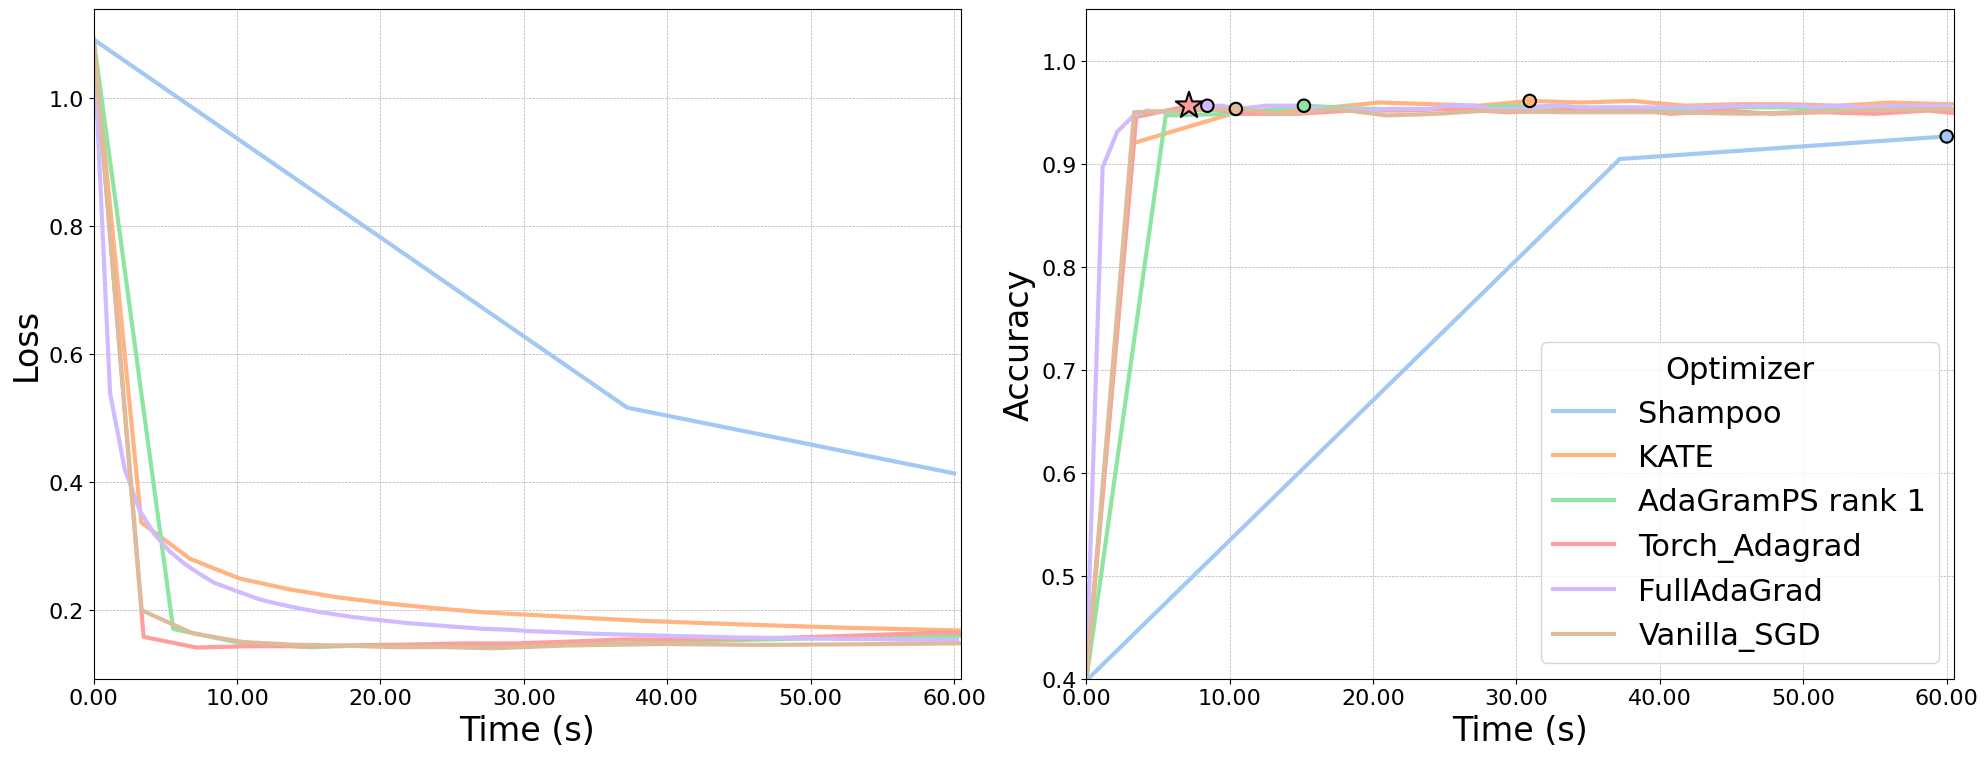

In [ ]:
dir = './plots'
os.makedirs(dir, exist_ok=True)

df_test = df_bin[df_bin['mode'] == 'test']
df_test.loc[(df_test['optimizer'] == 'Shampoo') & (df_test['epoch'] == 2), 'time'] = 60
best_accuracies = df_test.loc[df_test.groupby('optimizer')['accuracy'].idxmax()].reset_index(drop=True)
time_budget = 60


# --- Plotting Setup ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=False)

# Define optimizers and create maps for colors, markers, and sizes
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}
marker_map = {opt: 'o' for opt in optimizers}
marker_map['Torch_Adagrad'] = '*'
sizes_map = {opt: 80 for opt in optimizers}
sizes_map['Torch_Adagrad'] = 400

# --- Left Subplot: Loss vs. Time ---
sns.lineplot(data=df_test, x='time', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])
axes[0].set_xlabel('Time (s)', fontsize=24)
axes[0].set_ylabel('Loss', fontsize=24)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

# --- Right Subplot: Accuracy vs. Time ---
sns.lineplot(data=df_test, x='time', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])
sns.scatterplot(data=best_accuracies, x='time', y='accuracy', hue='optimizer',
                s=[sizes_map[opt] for opt in best_accuracies['optimizer']],
                edgecolor='black', linewidth=1.5, legend=False,
                zorder=5, palette=color_map, ax=axes[1], style='optimizer',
                markers=marker_map)
axes[1].set_xlabel('Time (s)', fontsize=24)
axes[1].set_ylabel('Accuracy', fontsize=24)
axes[1].set_ylim(0.4, 1.05)
axes[1].set_yticks(np.arange(0.4, 1.05, 0.1))
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# --- KEY CHANGES: X-axis Ticks and Formatting ---
formatter = mticker.FormatStrFormatter('%.2f')
for ax in axes:
    ax.set_xlim(0, time_budget + 0.5)
    # Set x-ticks to have a unit space value (every 1 second)
    ax.set_xticks(np.arange(0, time_budget + 0.5, 10))
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='both', which='major', labelsize=16)

# --- Legend Handling ---
handles, labels = axes[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axes[1].legend(unique_labels.values(), unique_labels.keys(),
               fontsize=22, loc='lower right', title='Optimizer', title_fontsize='22')

# --- Final Save and Show ---
output_path = os.path.join(dir, 'Splice_bin_classification_fixed_time.pdf')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(output_path, dpi=300)

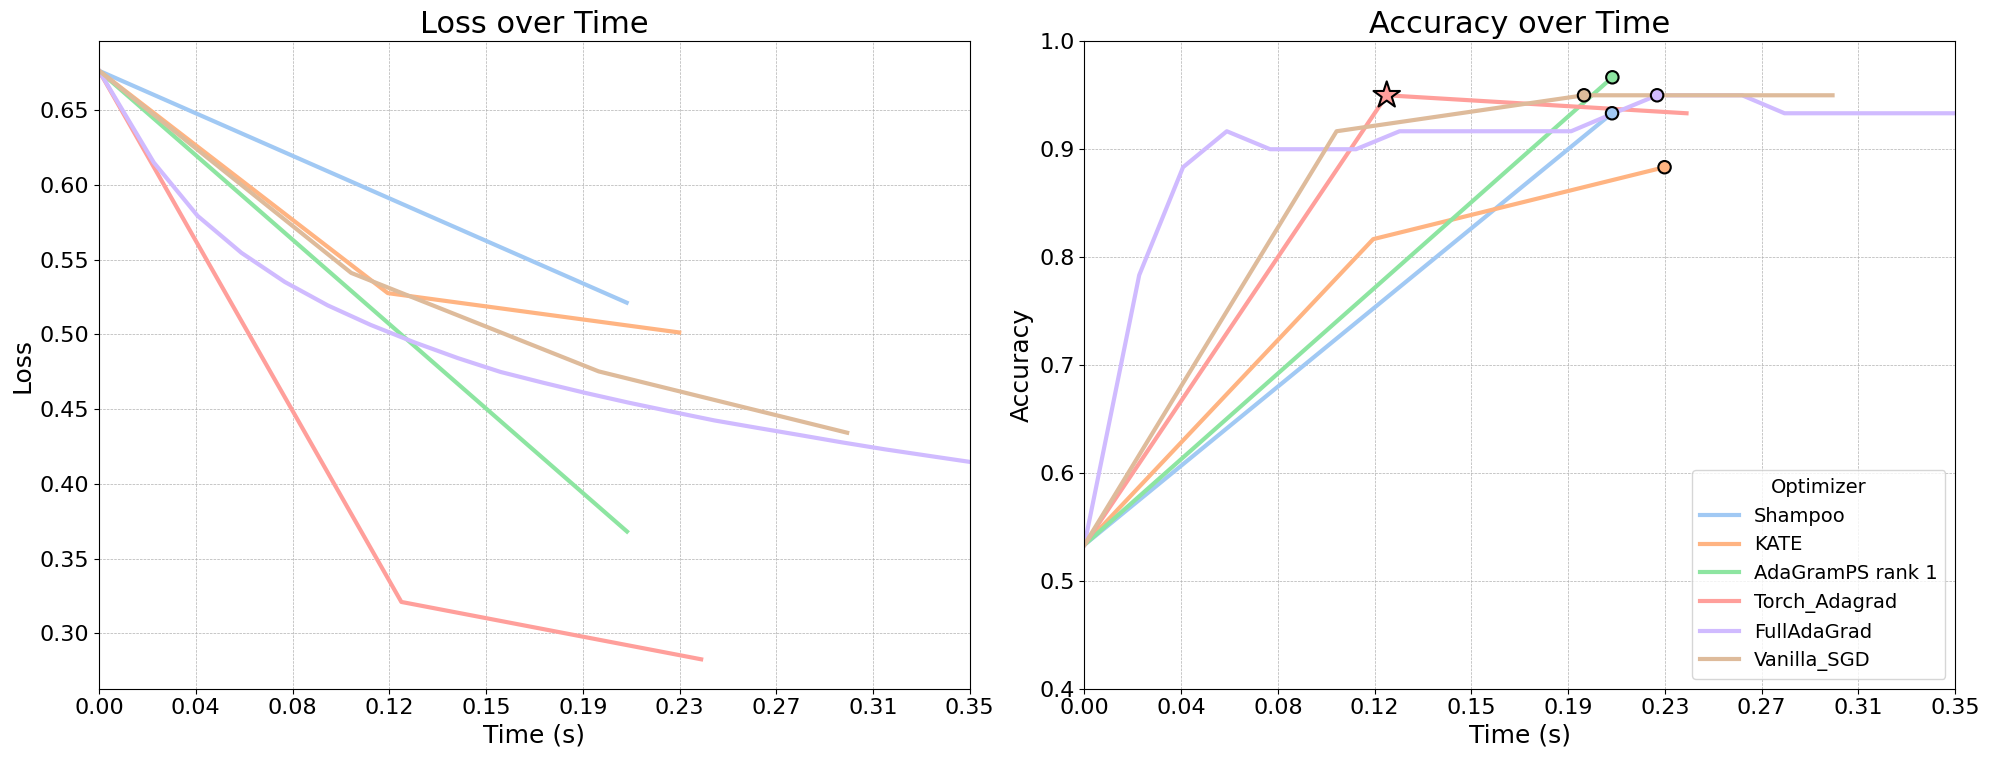

In [98]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import os

dir = './plots'
os.makedirs(dir, exist_ok=True)

# Data preparation
df_test = df_bin[df_bin['mode'] == 'test']

time_budget = df_test[df_test['optimizer'] == 'FullAdaGrad']['epoch_time'].max()
df_within_time = df_test[df_test['epoch_time'] <= time_budget].copy()
best_accuracies = df_within_time.loc[df_within_time.groupby('optimizer')['accuracy'].idxmax()].reset_index(drop=True)

min_time_limit = df_test['epoch_time'].min()

# --- Plotting Setup ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=False)

# Define optimizers and create maps for color, markers, and sizes
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}
marker_map = {opt: 'o' for opt in optimizers}
marker_map['Torch_Adagrad'] = '*'
sizes_map = {opt: 80 for opt in optimizers}
sizes_map['Torch_Adagrad'] = 400

# --- Left Subplot: Loss vs. Time ---
sns.lineplot(data=df_within_time, x='epoch_time', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])
axes[0].set_title('Loss over Time', fontsize=22)
axes[0].set_xlabel('Time (s)', fontsize=18)
axes[0].set_ylabel('Loss', fontsize=18)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].set_xlim(min_time_limit, time_budget)
axes[0].set_xticks(np.linspace(min_time_limit, time_budget, 10))

# --- Right Subplot: Accuracy vs. Time ---
sns.lineplot(data=df_within_time, x='epoch_time', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])
sns.scatterplot(data=best_accuracies, x='epoch_time', y='accuracy', hue='optimizer',
                s=[sizes_map[opt] for opt in best_accuracies['optimizer']],
                edgecolor='black', linewidth=1.5, legend=False,
                zorder=5, palette=color_map, ax=axes[1], style='optimizer',
                markers=marker_map)
axes[1].set_title('Accuracy over Time', fontsize=22)
axes[1].set_xlabel('Time (s)', fontsize=18)
axes[1].set_ylabel('Accuracy', fontsize=18)
axes[1].set_ylim(0.4, 1.0)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_yticks(np.arange(0.4, 1.01, 0.1))
axes[1].set_xlim(min_time_limit, time_budget)
axes[1].set_xticks(np.linspace(min_time_limit, time_budget, 10))


# --- Tick Formatting ---
formatter = mticker.FormatStrFormatter('%.2f')
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16)
    # --- CORRECTED PART ---
    # Apply the formatter to each subplot's x-axis here
    ax.xaxis.set_major_formatter(formatter)
    # --------------------

# --- Legend Handling ---
handles, labels = axes[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axes[1].legend(unique_labels.values(), unique_labels.keys(),
               fontsize=14, loc='lower right', title='Optimizer', title_fontsize='14')

# --- Final Save and Show ---
output_path = os.path.join(dir, 'psi_bin_classification_fixed_time.pdf')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(output_path, dpi=300)
plt.show()


NameError: name 'df_bin' is not defined

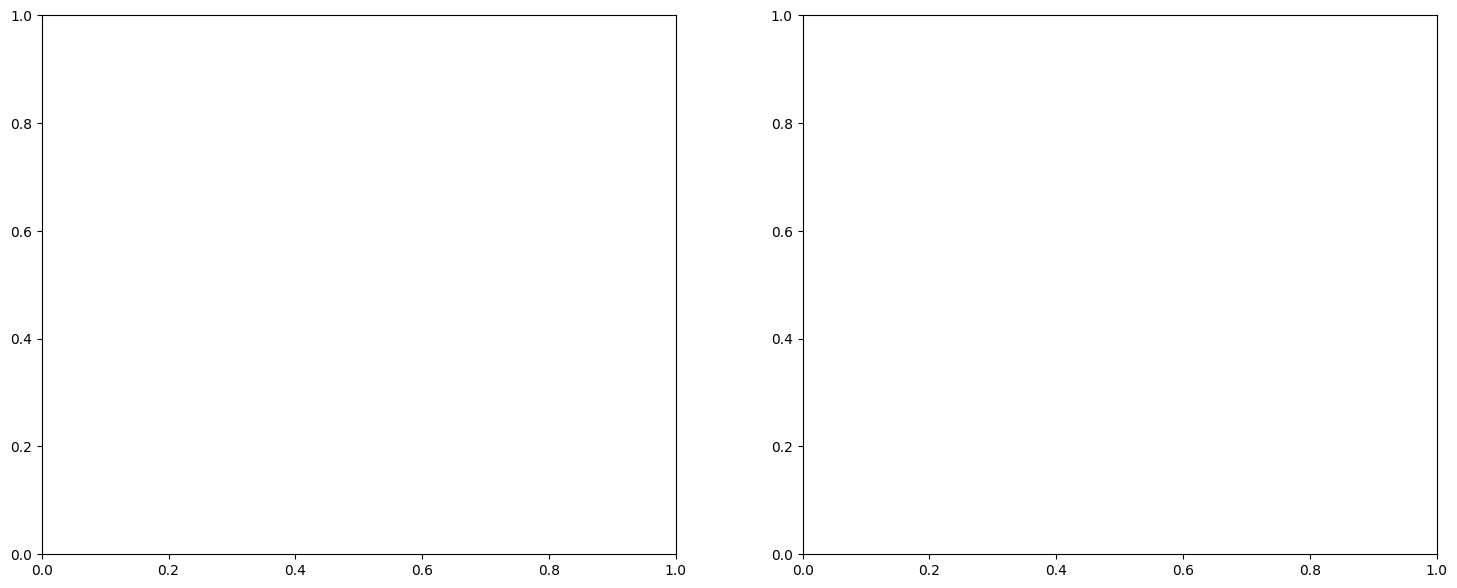

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame with 'loss' and 'accuracy' columns
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Plot loss over epochs
sns.lineplot(
    data=df_bin.query('mode == "test" and rank == 4'), 
    x='epoch', y='loss', hue='optimizer', 
    palette='pastel', linewidth=1.5, ax=axes[0]
)
# axes[0].set_title('Loss over Epochs', fontsize=20)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch', fontsize=16)
axes[0].set_ylabel('Loss', fontsize=16)

# Plot accuracy over epochs
sns.lineplot(
    data=df_bin.query('mode == "test" and rank == 4'),
    x='epoch', y='accuracy', hue='optimizer', 
    palette='pastel', linewidth=1.5, ax=axes[1]
)
# axes[1].set_title('Accuracy over Epochs', fontsize=20)
axes[1].set_xlabel('Epoch', fontsize=16)
axes[1].set_ylabel('Accuracy', fontsize=16)

# Adjust legend to only appear once on the right plot
axes[1].legend(title='Optimizer', fontsize=12, title_fontsize=14)

# Set main title
plt.suptitle('Binary Classification (20, 2)', fontsize=24)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.savefig('binclassification_plots.pdf', format='pdf', bbox_inches='tight')

plt.show()


## Matrix G evolution

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

# Directory containing G matrix files
matrix_dir = "../scripts/matrix_G/"
matrix_out_dir = "../scripts/matrix_G_pngs/"

def numerical_key(filename):
    # Extract numbers as integers; returns (inf,) if no number is found
    numbers = re.findall(r'\d+', os.path.basename(filename))
    return tuple(map(int, numbers)) if numbers else (float('inf'),)

# Find all .pt files in the directory
file_pattern = os.path.join(matrix_dir, "*.pt")
files = glob.glob(file_pattern)
files.sort(key=numerical_key)  # Sort for chronological order

print(f"Found {len(files)} G matrix files to process...")

# Process each file
for filename in files[:100]:
    try:
        # Extract just the filename without path for display
        base_filename = os.path.basename(filename)
        print(f"Processing: {base_filename}")
        
        # Load G matrix
        G_matrix = torch.load(filename, map_location='cpu')
        
        # Convert to numpy array for plotting
        G_numpy = G_matrix.numpy()
        
        # Create heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(G_numpy, cmap='viridis', aspect='auto')
        plt.colorbar(label='Values')
        
        # Extract epoch info from filename for better title
        if 'epoch_' and 'batch_' in base_filename:
            epoch_info = base_filename.split('epoch_')[1].split('_')[0]
            batch_info = base_filename.split('batch_')[1].split('_')[0]

            title = f'Heatmap of G Matrix - Epoch {epoch_info}, step {batch_info}'
        else:
            title = f'Heatmap of G Matrix - {base_filename}'
        
        plt.title(title)
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        
        # Create output filename (replace .pt with .png)
        output_filename = base_filename.replace('.pt', '.png')
        output_path = os.path.join(matrix_out_dir, output_filename)
        
        # Save the plot as PNG
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()  # Close the figure to free memory
        
        print(f"Saved: {output_filename}")
        
    except Exception as e:
        print(f"Error processing {base_filename}: {str(e)}")
        continue

print("Processing complete!")


Found 401 G matrix files to process...
Processing: G_matrix_epoch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_1_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_1_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_2_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_2_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_3_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_3_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_4_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_4_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_5_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_5_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_6_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_6_adagram_task_BinClass.png
Processing: G_mat

In [3]:
from PIL import Image
import glob
import os


def create_gif_from_pngs(pattern="*.png", output="output.gif", directory=".", duration=500, optimize=True):
    """Create GIF from PNG files matching the pattern in a specific directory"""
    
    # Construct full pattern with directory path
    full_pattern = os.path.join(directory, pattern)
    files = glob.glob(full_pattern)
    print(f"Looking in: {full_pattern}")
    print(f"Found files: {files}")
    

    files.sort(key=numerical_key)
    
    if not files:
        print(f"No files found matching pattern: {full_pattern}")
        return
    
    # Load images
    images = [Image.open(f) for f in files]
    
    # Create output path in the same directory
    output_path = os.path.join(directory, output)
    
    # Create GIF
    images[0].save(
        output_path,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0,
        optimize=optimize
    )
    
    print(f"GIF created: {output_path}")
    print(f"Frames: {len(images)}")

# Usage for your specific case
matrix_dir = "../scripts/matrix_G_pngs/"
create_gif_from_pngs("G_matrix_epoch_*.png", "matrix_evolution.gif", matrix_dir, duration=800)
create_gif_from_pngs("*.png", "all_matrices.gif", matrix_dir)


Looking in: ../scripts/matrix_G_pngs/G_matrix_epoch_*.png
Found files: ['../scripts/matrix_G_pngs\\G_matrix_epoch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_10_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_11_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_12_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_13_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_14_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_15_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_16_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_17_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_18_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_bat

In [15]:
# df_1 = pd.read_csv('results/loggs/nosvd_adagram_logs.csv')
# df_1["method"] = ["nosvd"] * len(df_1['lr'])

# df_2 = pd.read_csv('results/loggs/svd_adagram_logs_10.csv')
# df_2["method"] = ["svd"] * len(df_2['lr'])

# df_3 = pd.read_csv('results/loggs/psi_adagram_logs.csv')
# df_3["method"] = ["psi"] * len(df_3['lr'])

df_4 = pd.read_csv('results/loggs/svd_adagram_logs_1000.csv')
df_4["method"] = ["vanila"] * len(df_4['lr'])

df = pd.concat([df_4])


In [16]:
df = df.reset_index(drop=True)

## Loggs Statistics

In [126]:
import pandas as pd
import glob
import os
import re

def extract_metadata(filename):
    # Remove directory and extension
    base = os.path.basename(filename)
    name, _ = os.path.splitext(base)
    # Match optimizer and rank (e.g., nosvd_adagram_logs_2)
    match = re.match(r'([a-zA-Z]+)_adagram_logs_(\d+)', name)
    if match:
        optimizer = match.group(1)
        rank = int(match.group(2))
    elif name == 'adagram_vanila':
        optimizer = 'vanilla'
        rank = None
    else:
        print(name)
        optimizer = 'unknown'
        rank = None
    return optimizer, rank

csv_files = glob.glob('../scripts/results/loggs/*.csv')
print(csv_files)

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    optimizer, rank = extract_metadata(file)
    df['method'] = optimizer
    df['rank'] = rank
    dfs.append(df)

df_logs = pd.concat(dfs, ignore_index=True)


['../scripts/results/loggs\\adagram_full_adagrad.csv', '../scripts/results/loggs\\adagram_logs.csv']
adagram_full_adagrad
adagram_logs


C:\Users\tanya\AppData\Local\Temp\ipykernel_3556\76817871.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_logs = pd.concat(dfs, ignore_index=True)


In [127]:
df_logs.head(10)

,step,param_id,grad_norm,grad_std,beta,lr,error_norm,rank_U,rank_V,max_U,...,max_V,min_V,U_shape_0,U_shape_1,V_shape_0,V_shape_1,method,rank,error_norm_sqrt,error_svd
0,1,0,0.296793,0.047525,0.010150,0.1,1.305431e-07,1,1,0.031038,...,3.058051,-3.058052,40,1,40,1,unknown,None,1.489215e-06,0.0
1,1,1,0.621876,0.621876,0.002454,0.1,1.215315e-07,1,1,0.034131,...,13.905581,-13.905578,2,1,2,1,unknown,None,4.173457e-07,0.0
2,2,0,0.589780,0.094440,0.002798,0.1,4.061235e-07,2,2,0.031038,...,8.018862,-8.018860,40,2,40,2,unknown,None,1.640340e-01,0.0
3,2,1,0.786835,0.786834,0.237631,0.1,5.058030e-07,2,1,0.212329,...,13.905581,-13.905578,2,2,2,2,unknown,None,5.838632e-07,0.0
4,3,0,0.417742,0.066892,0.007681,0.1,6.821674e-07,3,3,0.034629,...,8.018862,-8.018860,40,3,40,3,unknown,None,2.221021e-01,0.0
5,3,1,0.545145,0.545145,0.410979,0.1,2.143909e-07,2,1,0.212329,...,13.905581,-13.905578,2,3,2,3,unknown,None,3.910181e-06,0.0
6,4,0,0.747261,0.119657,0.003344,0.1,1.068096e-06,4,4,0.034629,...,8.018862,-8.018860,40,4,40,4,unknown,None,1.097406e-01,0.0
7,4,1,0.651999,0.651999,0.403631,0.1,2.412969e-07,2,1,0.212329,...,13.905581,-13.905578,2,4,2,4,unknown,None,2.040443e-06,0.0
8,5,0,0.318926,0.051069,0.013376,0.1,1.029970e-06,5,5,0.034629,...,8.018862,-8.018860,40,5,40,5,unknown,None,1.474491e-01,0.0
9,5,1,0.502910,0.502910,0.451078,0.1,1.533394e-07,2,1,0.212329,...,13.905581,-13.905578,2,5,2,5,unknown,None,6.497063e-07,0.0


c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


<Figure size 1500x800 with 0 Axes>

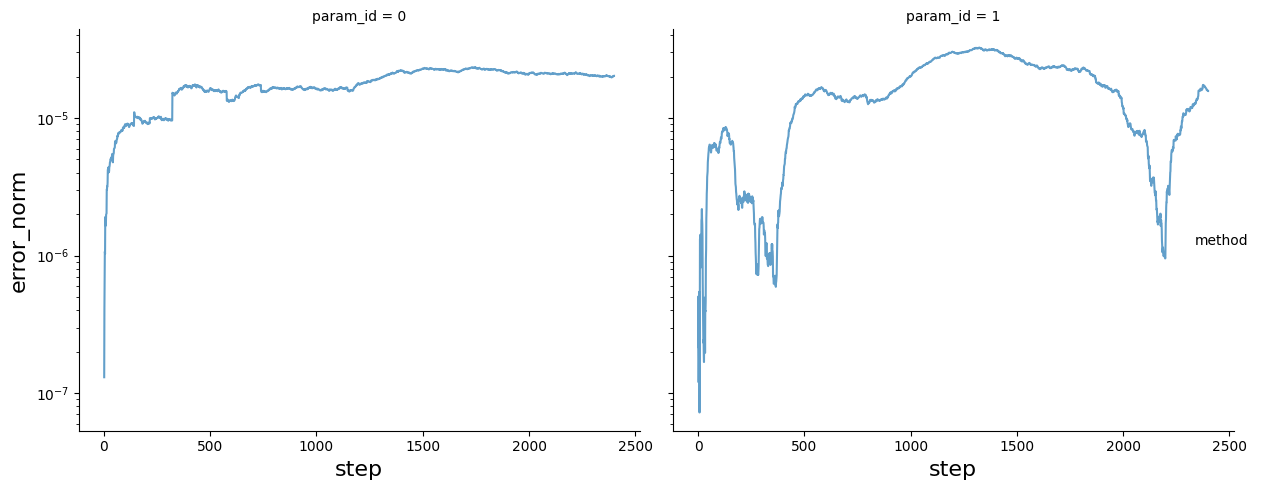

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df_logs,
    col='param_id',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='step',
    # y='avg_epoch_time',
    y='error_norm',
    # style='method',
    # hue='rank',
    palette='pastel',
    alpha = 0.7,
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='method', title_fontsize='15', fontsize='12')

# grid.fig.suptitle(f'LinRegression({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="param_id = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()